In [1]:
"""
Created on Mon Dec  8 14:55:29 2025
@author: Yann Schmitt
Modified by S. Plana-Ruiz, last 10/07/2026
"""
import os
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

#No baseline, no x-offset
def Gauss(x, A, sigma):
    return A * np.exp(-x**2 / (2 * sigma**2))

In [4]:
#Fit params 
own_guess_key = 0 #Own initial fit params
sigma0 = 0.015 #Used if own_guess_key = 1
A0 = 25000  #Used if own_guess_key = 1

#Global params histogram display
bin_num = 500 #number of bins
plt.rc('lines', linewidth=2, linestyle = "-") #line width
fit_curve_col = "red" #color fit curve
rwidth_key = 1 #rel. size of showed bin
ec_key = "black" #bin edge colour
lw_key = 0 #line width bin edge
bin_color = "blue" #color bins
grid_key = 0 #diagram grid
labels = 1 #display data point labels
sigma_level_plot = 1 #display dashed lines at 3x sigma

#output handling
dir_output = r"F:\SerialPED_organics\DESP\DESP_Script" 
hist_save = 1 #Save bins, counts for external plotting in xy format
plot_output = 1 #Save plots as png 

Histogram saved under F:\SerialPED_organics\DESP\DESP_Script\tricli_dyn_Uiso_withHsrefined_oriRefined_aniso_F2_MogulRestrictions_diffFourier_histogram.txt



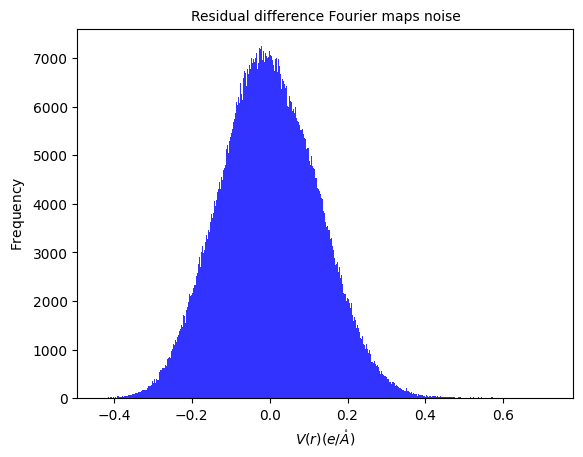

In [14]:
#Input file in JMAP3D format
density_file = r"F:\SerialPED_organics\DESP\tricli_dyn_Uiso_withHsrefined_oriRefined_aniso_F2_MogulRestrictions_diffFourier.3d"
# density_file = r"F:\SerialPED_organics\DESP\tricli_withDynModel_extinctionCorrected_MogulRestrictions_diffFourier.3d"
# density_file = r"F:\SerialPED_organics\DESP\mono_dyn_Uiso_withHsrefined_2_oriRefined_withNewReflFile_F2_aniso_MogulRestrictions_diffFourier.3d"
# density_file = r"F:\SerialPED_organics\DESP\mono_refining_aniso_withDynModel_newReflFile_MogulRestrictions_diffFourier.3d"

name, ext = os.path.splitext(density_file) 
file_name = name.split("\\")[-1]
f = open(density_file, "r")
file_list = f.readlines()

#Read header
comments = file_list[0].split()
#Define axes
number_divisions = file_list[1].split(",")
#Note to me: Output axis dimensions and resolution step for file format without header and future stuff

file_list_cut = file_list[2:]
#Create array
density_array = np.array([(x.split(",")[-1]) for x in file_list_cut])
density_array = [float(x)*3.32367 for x in density_array]

#Plot histogram raw noise
plt.clf()
plt.title("Residual difference Fourier maps noise", fontsize=10)
plt.xlabel("$V(r) ( e / \mathring{A})$")
plt.ylabel("$\mathrm{Frequency}$")
res = plt.hist(density_array, bins = bin_num, rwidth = rwidth_key, color=bin_color, lw = lw_key, ec=ec_key, alpha = 0.8)
plt.savefig(dir_output + "\\" + file_name + "_histogram.png", dpi = 300, bbox_inches='tight')

n = len(res[0])
x_density_array = np.zeros((n),dtype=float) 
for x in range(n):
    x_density_array[x]=(res[1][x+1]+res[1][x])/2

if hist_save == 1:
    c = [res[1], res[0]]
    path =  dir_output + "\\" + file_name + "_histogram.txt"
    with open(path, "w") as file:
        for x in zip(*c):
            file.write("{0}\t{1}\n".format(*x))
    print("Histogram saved under " + path + "\n")

In [15]:
####################################################### Gaussian Fit #######################################################
if own_guess_key == 1:
    sigma = sigma0 
    A = A0
else:
    #Guess for amplitude
    A= np.max(res[0])

    #Sigma guess via fwhm
    res_max = np.max(res[0])
    half_max = res_max / 2
    indices = np.where(res[0] > half_max)[0]
    fwhm = x_density_array[indices[-1]] - x_density_array[indices[0]]
    sigma = fwhm / 2.355 #Strictly only for pure guassian
    
#LSO
parameters, pcov = curve_fit(Gauss, x_density_array, res[0], p0=[A, sigma])
fit_A, fit_B = parameters
x_plot = np.linspace(np.min(res[1]),np.max(res[1]),500)
fit_density_array = Gauss(x_density_array, fit_A, fit_B)
residuals = res[0] - fit_density_array

#error form covariance matrix
perr = np.sqrt(np.diag(pcov))

#Overview Params and errors
print("\n******Fit Params Overview******\n")
print("Amplitude Initial: " + str(A))
print("Sigma Initial: " + str(sigma))
print(f"Amplitude Gauss: {parameters[0]:.4f} +/- {perr[0]:.4f}")
print(f"Sigma Gauss: {parameters[1]:.4f} +/- {perr[1]:.4f}")
print(f"FWHM Gauss: {2.355 * parameters[1]:.4f} +/- {2.355 * perr[1]:.4f}")

#Save parameters:
pathGaussFit =  dir_output + "\\" + file_name + "_GaussianFit.txt"
file = open(pathGaussFit, "w")
file.write("******Fit Params Overview******\n")
file.write("Amplitude Initial: " + str(A)+"\n")
file.write("Sigma Initial: " + str(sigma)+"\n")
file.write(f"Amplitude Gauss: {parameters[0]:.4f} +/- {perr[0]:.4f}"+"\n")
file.write(f"Sigma Gauss: {parameters[1]:.4f} +/- {perr[1]:.4f}"+"\n")
file.write(f"FWHM Gauss: {2.355 * parameters[1]:.4f} +/- {2.355 * perr[1]:.4f}")
file.close()


******Fit Params Overview******

Amplitude Initial: 7237.0
Sigma Initial: 0.12586825953369876
Amplitude Gauss: 7062.1744 +/- 16.2709
Sigma Gauss: 0.1277 +/- 0.0003
FWHM Gauss: 0.3008 +/- 0.0008



Plots saved under F:\SerialPED_organics\DESP\DESP_Script\Residual density plot tricli_dyn_Uiso_withHsrefined_oriRefined_aniso_F2_MogulRestrictions_diffFourier


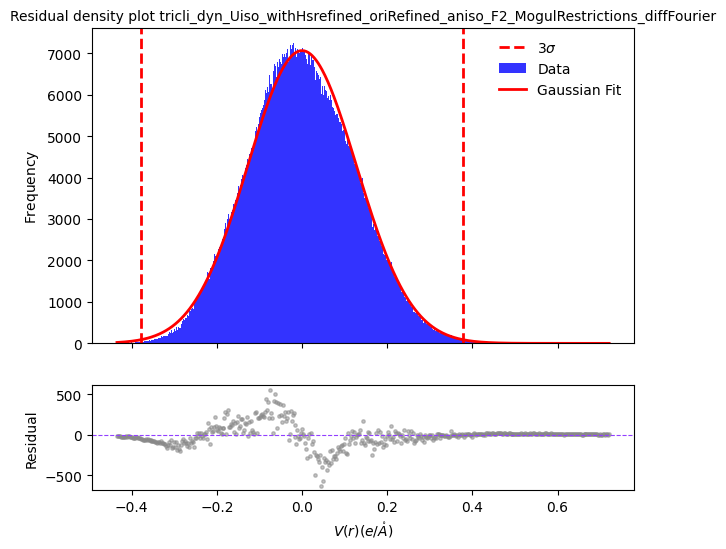

In [16]:
####################################################### Plots #######################################################
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(7, 6),
                                gridspec_kw={'height_ratios': [3, 1]},
                                sharex=True)

title = "Residual density plot" + " " + file_name
if sigma_level_plot == 1:
    ax1.axvline(3*sigma, color = "red", linestyle = "--", label = "$3 \sigma$")
    ax1.axvline(-3*sigma, color = "red", linestyle = "--")
if labels == 1:
    ax1.set_ylabel("$\mathrm{Frequency}$")
    ax1.set_title(title, fontsize=10)
if grid_key == 1:
    ax1.grid()
    
ax1.hist(density_array, bins = bin_num, rwidth = rwidth_key, color=bin_color, lw = lw_key, ec=ec_key, alpha = 0.8, label= "Data")
ax1.plot(x_density_array, fit_density_array, color=fit_curve_col, label= "Gaussian Fit")
ax1.legend(frameon=False)


ax2.scatter(x_density_array, residuals, s=6, color='#888888', alpha=0.5, label = "Data")
ax2.axhline(0, color='#9240ff', linewidth=0.8, linestyle='--')
ax2.set_xlabel("$V(r) ( e / \mathring{A})$")
ax2.set_ylabel('Residual')
if grid_key == 1:
    ax2.grid()
    
if plot_output == 1:
    path =  dir_output + "\\" + title
    print("\nPlots saved under " + path) 
    plt.savefig(path, dpi = 300, bbox_inches='tight')
    
plt.show()